<a href="https://colab.research.google.com/github/cacjr/RN-Eurosat-CNN-vs-Transfer-Learning/blob/main/GS_FIAP_RN_2sem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GLOBAL SOLUTION 2026.1 — Deep Learning e Visão Computacional

# Classificação Inteligente de Imagens de Satélite para Apoio à Nova Economia Espacial

> **Notebook estruturado como relatório de Ciência de Dados**, contemplando todos os critérios da rubrica, boas práticas metodológicas e técnicas avançadas de Deep Learning.


## Identificação do Grupo

| Campo | Informação |
|---|---|
| **Integrantes** | Claudio Alves · Rodrigo Wolkoff · Luna Rousseau |
| **Curso / Turma** | Inteligência Artificial |
| **Professor(a)** | Juliana Scudilio |
| **Título do projeto** | Classificação Inteligente de Imagens de Satélite com CNNs e Transfer Learning |

---


## 1. Introdução

### 1.1 Contextualização na Nova Economia Espacial

A crescente disponibilidade de imagens de satélite — impulsionada por programas como o **Copernicus** (ESA/EU) e por empresas da Nova Economia Espacial como Planet Labs, Airbus Defence & Space e Maxar Technologies — transformou radicalmente a capacidade de monitoramento do planeta em escala global e em tempo quase real.

Nesse contexto, a interpretação manual de grandes volumes de imagens orbitais tornou-se inviável. Técnicas de **Deep Learning**, em especial as **Redes Neurais Convolucionais (CNNs)**, emergem como a solução tecnológica central para automatizar a extração de informações geoespaciais relevantes a partir dessas imagens.

### 1.2 Definição do Problema

O problema abordado neste projeto consiste na **classificação automática de imagens de satélite** em dez categorias de cobertura terrestre, utilizando o dataset **EuroSAT** — derivado das imagens multiespectrais do satélite Sentinel-2.

### 1.3 Objetivo

Desenvolver, treinar, avaliar e comparar dois modelos de Deep Learning:
1. Uma **CNN construída do zero**, para compreender os fundamentos arquiteturais;
2. Um modelo de **Transfer Learning com MobileNetV2**, para avaliar o ganho obtido com conhecimento pré-treinado.

### 1.4 Impacto Social, Ambiental e Econômico

| Domínio | Aplicação |
|---|---|
| Ambiental | Monitoramento de desmatamento, expansão de corpos d'água, queimadas |
| Agrícola | Agricultura de precisão, estimativa de safras, irrigação inteligente |
| Urbano | Mapeamento de expansão urbana irregular, planejamento territorial |
| Hídrico | Gestão de bacias, detecção precoce de secas |
| Industrial | Monitoramento de infraestrutura crítica |

### 1.5 Arquitetura Geral da Solução

```
Imagens EuroSAT (Sentinel-2)
        │
        ▼
  Pré-processamento
  (Resize · Normalização · Data Augmentation)
        │
        ├──► CNN Própria (3 blocos conv) ──► Avaliação
        │
        └──► MobileNetV2 (Transfer Learning) ──► Avaliação
                                                      │
                                              Comparação Final
                                          Matriz de Confusão · F1-Score
```

---


## 2. Configuração do Ambiente e Importações

In [ ]:
# ── Importações ────────────────────────────────────────────────────────────────
import os, sys, random, zipfile, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)
from tensorflow.keras.applications import MobileNetV2

# ── Reprodutibilidade ───────────────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Hiperparâmetros globais ─────────────────────────────────────────────────────
IMG_SIZE        = (128, 128)   # resolução compatível com MobileNetV2 e CNN
BATCH_SIZE      = 64           # batch maior → mais velocidade com GPU
IMAGENS_CLASSE  = 1000         # amostra equilibrada por classe (total ~10k)
EPOCHS          = 20           # teto; EarlyStopping interrompe antes se necessário
VAL_SPLIT       = 0.15         # 15 % validação
TEST_SPLIT      = 0.15         # 15 % teste  →  70 % treino efetivo
AUTOTUNE        = tf.data.AUTOTUNE

print(f"TensorFlow  : {tf.__version__}")
print(f"GPUs disponíveis: {tf.config.list_physical_devices('GPU')}")
print(f"IMG_SIZE={IMG_SIZE} | BATCH={BATCH_SIZE} | Imagens/classe={IMAGENS_CLASSE}")


TensorFlow  : 2.20.0
GPUs disponíveis: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
IMG_SIZE=(128, 128) | BATCH=64 | Imagens/classe=1000


## 3. Apresentação e Exploração do Dataset

### 3.1 EuroSAT — Visão Geral

O **EuroSAT** é um benchmark amplamente utilizado na comunidade de visão computacional e sensoriamento remoto. Suas imagens foram capturadas pelo satélite **Sentinel-2** (programa Copernicus / ESA), com resolução espacial de **10 metros por pixel**, cobrindo regiões da Europa.

| Característica | Detalhe |
|---|---|
| Total de imagens | ~27.000 |
| Dimensão original | 64 × 64 px (RGB) |
| Número de classes | 10 |
| Fonte | Sentinel-2 / ESA Copernicus |
| Aplicação típica | Classificação de cobertura e uso do solo (LULC) |

### 3.2 Classes do Dataset

| Classe | Descrição |
|---|---|
| AnnualCrop | Plantações anuais (trigo, milho etc.) |
| Forest | Florestas densas |
| HerbaceousVegetation | Vegetação rasteira (prados, campos) |
| Highway | Rodovias e acessos |
| Industrial | Zonas industriais e logísticas |
| Pasture | Pastagens |
| PermanentCrop | Culturas permanentes (vinhedos, pomares) |
| Residential | Áreas residenciais urbanas |
| River | Rios e cursos d'água |
| SeaLake | Mares, lagos e reservatórios |

> **Relação com a Nova Economia Espacial:** o EuroSAT simula diretamente os desafios enfrentados por sistemas de Earth Observation (EO) comerciais, onde classificar automaticamente o uso do solo em tempo real é um serviço de alto valor agregado.


### 3.3 Carregamento e Amostragem Otimizada do Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Configuração de caminhos ────────────────────────────────────────────────────
ZIP_PATH     = "/content/drive/MyDrive/Colab Notebooks/RN-GS-2sem.zip"
DATASET_PATH = "/content/eurosat_sample/EuroSAT/EuroSAT/EuroSAT/EuroSAT"

# ── Extração com amostragem equilibrada ─────────────────────────────────────────
# Selecionamos IMAGENS_CLASSE imagens por classe para manter dataset balanceado
# e reduzir tempo de I/O sem comprometer a representatividade.
if not os.path.exists(DATASET_PATH):
    os.makedirs(DATASET_PATH, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        arquivos = zf.namelist()
        classes = {}
        for arq in arquivos:
            partes = arq.split('/')
            if len(partes) < 2:
                continue
            classe = partes[-2]
            if arq.lower().endswith(('.jpg', '.jpeg', '.png')):
                classes.setdefault(classe, []).append(arq)
        for classe, imgs in classes.items():
            selecionadas = random.sample(imgs, min(IMAGENS_CLASSE, len(imgs)))
            for img in selecionadas:
                zf.extract(img, DATASET_PATH)
    print("Extração concluída.")
else:
    print("Dataset já extraído — pulando etapa.")

# ── Contagem real de imagens por classe ─────────────────────────────────────────
classes_found = sorted([
    d for d in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, d))
])
print(f"\nClasses encontradas ({len(classes_found)}):")
total = 0
for c in classes_found:
    n = len(os.listdir(os.path.join(DATASET_PATH, c)))
    print(f"  {c:<25}: {n} imagens")
    total += n
print(f"\nTotal de imagens: {total}")


Dataset já extraído — pulando etapa.

Classes encontradas (10):
  AnnualCrop               : 1000 imagens
  Forest                   : 1000 imagens
  HerbaceousVegetation     : 1000 imagens
  Highway                  : 1000 imagens
  Industrial               : 1000 imagens
  Pasture                  : 1000 imagens
  PermanentCrop            : 1000 imagens
  Residential              : 1000 imagens
  River                    : 1000 imagens
  SeaLake                  : 1000 imagens

Total de imagens: 10000


### 3.4 Divisão Treino / Validação / Teste

A divisão correta dos dados é um dos pilares metodológicos de qualquer projeto de Machine Learning:

| Conjunto | Proporção | Papel |
|---|---|---|
| **Treino** | 70 % | Ajuste dos pesos da rede via backpropagation |
| **Validação** | 15 % | Monitoramento durante o treinamento; seleção de hiperparâmetros |
| **Teste** | 15 % | Avaliação **final e imparcial** — não é visto durante o treino |

> **Por que ter um conjunto de teste separado?** Usar a validação como avaliação final produz métricas viesadas, pois decisões de treinamento (ex.: `EarlyStopping`, `ReduceLROnPlateau`) são guiadas pela loss de validação. O teste garante uma estimativa não contaminada da performance real do modelo.


In [ ]:
# ── Divisão estratificada manual: Treino / Validação / Teste ────────────────────
from sklearn.model_selection import train_test_split

all_paths, all_labels = [], []
class_names = sorted(classes_found)
num_classes  = len(class_names)
label_map    = {c: i for i, c in enumerate(class_names)}

for c in class_names:
    folder = os.path.join(DATASET_PATH, c)
    for fname in os.listdir(folder):
        if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(folder, fname))
            all_labels.append(label_map[c])

# Primeiro split: separa teste (15 %)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    all_paths, all_labels,
    test_size=TEST_SPLIT,
    stratify=all_labels,
    random_state=SEED
)

# Segundo split: separa validação dos restantes (15 % do total ≈ 17,6 % do trainval)
val_ratio = VAL_SPLIT / (1 - TEST_SPLIT)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=val_ratio,
    stratify=y_trainval,
    random_state=SEED
)

print(f"Treino    : {len(X_train):>5} imagens")
print(f"Validação : {len(X_val):>5} imagens")
print(f"Teste     : {len(X_test):>5} imagens")
print(f"Classes   : {class_names}")


Treino    :  7000 imagens
Validação :  1500 imagens
Teste     :  1500 imagens
Classes   : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    jpgs = [f for f in files if f.lower().endswith((".jpg",".jpeg",".png"))]

    if jpgs:
        print("\nIMAGENS ENCONTRADAS EM:")
        print(root)
        print("Quantidade:", len(jpgs))
        print("Exemplo:", jpgs[:3])
        break


IMAGENS ENCONTRADAS EM:
/content/eurosat_sample/EuroSAT/EuroSAT/EuroSAT/EuroSAT/SeaLake
Quantidade: 1000
Exemplo: ['SeaLake_35.jpg', 'SeaLake_2184.jpg', 'SeaLake_206.jpg']


### 3.5 Pipeline Profissional com tf.data

Utilizamos `tf.data` com `.cache()`, `.shuffle()` e `.prefetch(AUTOTUNE)` para maximizar a utilização da GPU e eliminar gargalos de I/O.

O **Data Augmentation** é aplicado **apenas ao conjunto de treino**, embutido diretamente no pipeline — evitando que imagens aumentadas vazem para validação ou teste.


In [ ]:
# ── Augmentation (apenas treino) ────────────────────────────────────────────────
# Escolhas justificadas para imagens de satélite:
# - RandomFlip: imagens aéreas não têm orientação canônica
# - RandomRotation: perspectiva orbital é isotrópica
# - RandomZoom: simula variação de altitude/resolução
# - RandomContrast: simula variações de iluminação e sazonalidade
augmentation_layer = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.10),
], name="data_augmentation")

# ── Função de leitura de imagem ─────────────────────────────────────────────────
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0   # normalização [0, 1]
    return img, label

def load_and_augment(path, label):
    img, label = load_image(path, label)
    img = augmentation_layer(img, training=True)
    return img, label

# ── Criação dos datasets ─────────────────────────────────────────────────────────
def make_dataset(paths, labels, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_and_augment if augment else load_image,
                num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE)
    ds = ds.cache()
    if augment:
        ds = ds.shuffle(buffer_size=2000, seed=SEED)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train, y_train, augment=True)
val_ds   = make_dataset(X_val,   y_val,   augment=False)
test_ds  = make_dataset(X_test,  y_test,  augment=False)

print("Pipelines criados com sucesso.")
print(f"Batches de treino   : {len(train_ds)}")
print(f"Batches de validação: {len(val_ds)}")
print(f"Batches de teste    : {len(test_ds)}")


Pipelines criados com sucesso.
Batches de treino   : 110
Batches de validação: 24
Batches de teste    : 24


## 4. Exploração Visual do Dataset

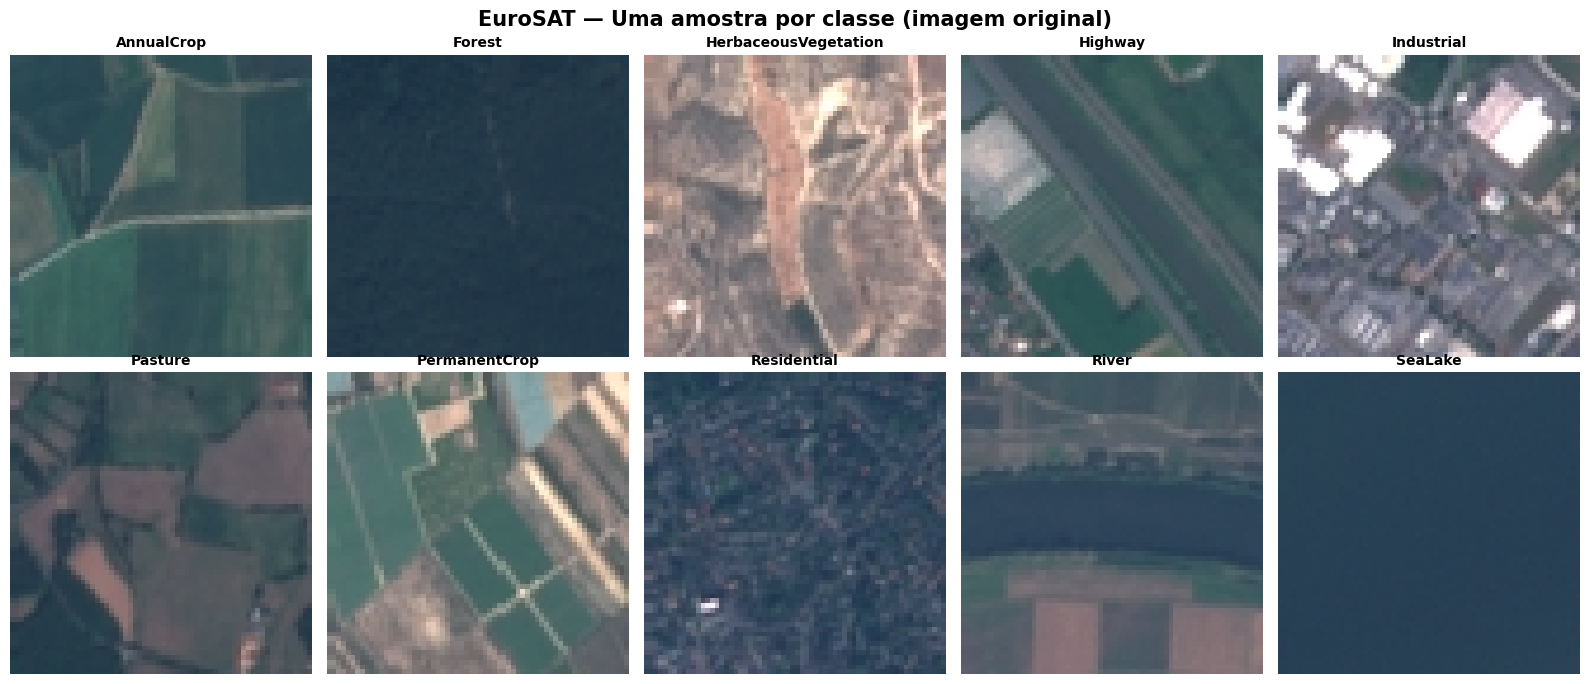

In [ ]:
# ── Amostras visuais por classe ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle("EuroSAT — Uma amostra por classe (imagem original)",
             fontsize=15, fontweight='bold')

for ax, cls in zip(axes.flatten(), class_names):
    folder = os.path.join(DATASET_PATH, cls)
    img_path = os.path.join(folder, random.choice(os.listdir(folder)))
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.set_title(cls, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()


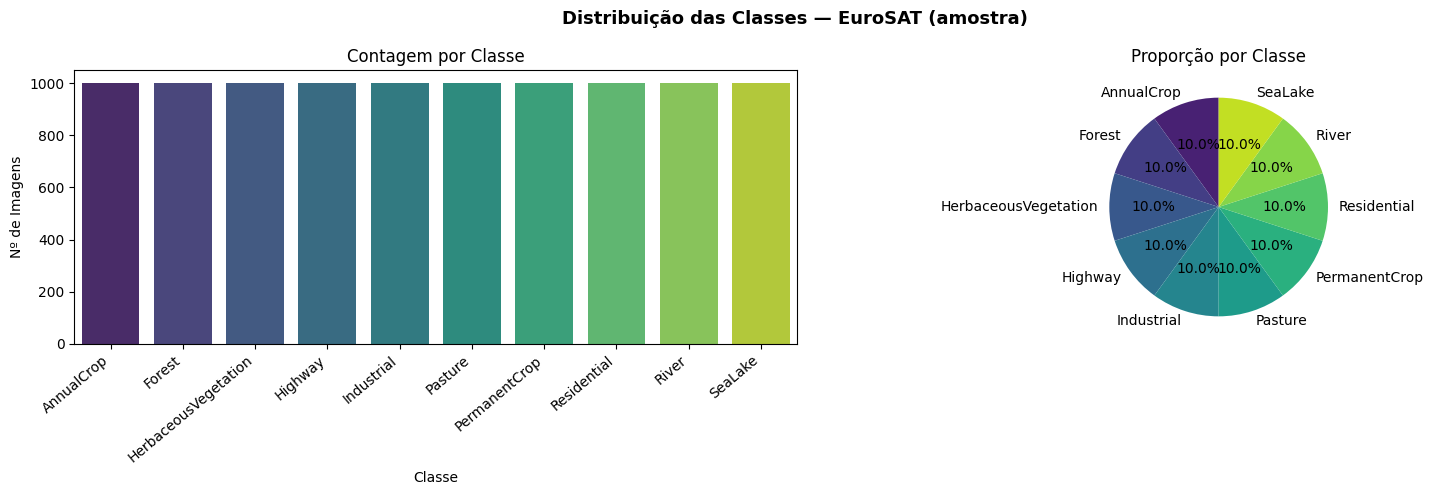

,Classe,Quantidade
0,AnnualCrop,1000
1,Forest,1000
2,HerbaceousVegetation,1000
3,Highway,1000
4,Industrial,1000
5,Pasture,1000
6,PermanentCrop,1000
7,Residential,1000
8,River,1000
9,SeaLake,1000


In [ ]:
# ── Distribuição das classes ─────────────────────────────────────────────────────
dist_data = {c: len(os.listdir(os.path.join(DATASET_PATH, c))) for c in class_names}
df_dist = pd.DataFrame({'Classe': dist_data.keys(), 'Quantidade': dist_data.values()})
df_dist = df_dist.sort_values('Quantidade', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Distribuição das Classes — EuroSAT (amostra)', fontsize=13, fontweight='bold')

# Barplot
sns.barplot(data=df_dist, x='Classe', y='Quantidade', palette='viridis', ax=axes[0])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=40, ha='right')
axes[0].set_title('Contagem por Classe')
axes[0].set_ylabel('Nº de Imagens')

# Pie chart
axes[1].pie(df_dist['Quantidade'], labels=df_dist['Classe'],
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('viridis', len(class_names)))
axes[1].set_title('Proporção por Classe')

plt.tight_layout()
plt.show()

display(df_dist)


### 4.1 Interpretação da Distribuição

A distribuição entre as classes é **praticamente equilibrada** (~1.000 imagens por classe), o que é uma característica intencional do EuroSAT. Isso favorece o treinamento porque:

- **Evita viés de classe majoritária:** a rede não tende a prever classes mais frequentes;
- **Facilita o uso de métricas macro:** F1-Score macro é uma métrica justa quando as classes são balanceadas;
- **Não exige técnicas de balanceamento** como oversampling ou class weights.

Apesar do equilíbrio numérico, algumas classes compartilham **padrões visuais semelhantes** (ex.: `HerbaceousVegetation` vs `Pasture`, `Highway` vs `River`), o que representa o principal desafio de classificação deste dataset.


## 5. Pré-processamento

### Decisões e Justificativas

| Etapa | Decisão | Justificativa |
|---|---|---|
| **Resize** | 128 × 128 px | Compatível com MobileNetV2; reduz custo computacional sem perda significativa de informação para imagens de 64×64 originais |
| **Normalização** | Divisão por 255 → [0, 1] | Estabilidade numérica; gradientes mais equilibrados durante backpropagation |
| **Divisão** | 70 / 15 / 15 % | Garante conjunto de teste independente para avaliação final não viesada |
| **Augmentation** | flip H+V, rotação, zoom, contraste | Adequado a imagens de satélite (sem orientação canônica, variações sazonais) |
| **Pipeline tf.data** | cache + shuffle + prefetch | Elimina gargalo de I/O; maximiza utilização da GPU |

> O augmentation foi inserido **dentro do pipeline de treino**, não no modelo, garantindo que validação e teste recebam sempre a imagem original.


## 6. Desenvolvimento da CNN

### 6.1 Arquitetura e Justificativa

A CNN foi projetada para ser **eficiente computacionalmente**, mantendo capacidade de aprendizado adequada para 10 classes em imagens 128×128.

**Princípios de design:**

| Elemento | Decisão | Razão |
|---|---|---|
| Blocos Conv + BN + Pool | 4 blocos progressivos (32→64→96→128 filtros) | Extração hierárquica de features: bordas → texturas → padrões complexos |
| BatchNormalization | Após cada Conv | Acelera convergência, reduz sensibilidade ao learning rate |
| MaxPooling2D | Após cada bloco | Reduz dimensionalidade, confere invariância a pequenas translações |
| GlobalAveragePooling2D | Substitui Flatten | Reduz parâmetros drasticamente; boa regularização implícita |
| Dropout(0.4) | Antes da Dense final | Regularização; reduz co-adaptação entre neurônios |
| Softmax | Saída com 10 neurônios | Classificação multiclasse com probabilidades normalizadas |


In [ ]:
# ── Arquitetura CNN desenvolvida do zero ────────────────────────────────────────
def build_cnn(num_classes, input_shape=(128, 128, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        # Bloco 1 — features de baixo nível (bordas, gradientes)
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),          # 128→64

        # Bloco 2 — texturas e padrões simples
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),          # 64→32

        # Bloco 3 — padrões intermediários (formas, estruturas)
        layers.Conv2D(96, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),          # 32→16

        # Bloco 4 — features de alto nível (semântica da cena)
        layers.Conv2D(128, 3, padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),          # 16→8

        # Cabeça classificadora
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax'),
    ], name="CNN_EuroSAT")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_cnn(num_classes)
cnn_model.summary()


Model: "CNN_EuroSAT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 96)     │        55,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       110,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 251,146 (981.04 KB)

 Trainable params: 250,314 (977.79 KB)

 Non-trainable params: 832 (3.25 KB)

## 7. Técnicas Avançadas de Regularização e Treinamento

### Justificativa detalhada de cada técnica

| Técnica | Configuração | Por quê essa escolha |
|---|---|---|
| **Data Augmentation** | flip H+V, rot 15°, zoom 15%, contraste 10% | Imagens de satélite são isótropas — qualquer orientação é válida. Contraste simula sazonalidade |
| **BatchNormalization** | Após cada Conv2D | Reduz covariate shift interno; permite learning rates maiores; atua como regularizador leve |
| **Dropout(0.4)** | Antes da Dense final | Força a rede a aprender features redundantes; reduz overfitting |
| **EarlyStopping** | patience=7, restore_best_weights=True | Interrompe quando val_loss para de melhorar; recupera os melhores pesos automaticamente |
| **ReduceLROnPlateau** | factor=0.5, patience=4 | Reduz o learning rate pela metade quando a val_loss estagna; auxilia a sair de platôs |
| **ModelCheckpoint** | salva melhor modelo por val_accuracy | Garante que o melhor checkpoint seja preservado mesmo se o treinamento continuar além |
| **Transfer Learning** | MobileNetV2 pré-treinada + Fine-Tuning | Aproveita representações aprendidas em ImageNet; Fine-Tuning adapta as camadas superiores ao domínio de satélite |


In [ ]:
# ── Callbacks compartilhados ────────────────────────────────────────────────────
def get_callbacks(model_name, monitor='val_loss'):
    return [
        EarlyStopping(
            monitor=monitor,
            patience=7,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor=monitor,
            factor=0.5,
            patience=4,
            min_lr=1e-6,
            verbose=1
        ),
        ModelCheckpoint(
            filepath=f"{model_name}_best.keras",
            monitor='val_accuracy',
            save_best_only=True,
            verbose=0
        )
    ]


## 8. Treinamento da CNN

In [ ]:
# ── Treinamento ─────────────────────────────────────────────────────────────────
print("Iniciando treinamento da CNN própria...")
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('cnn_eurosat'),
    verbose=1
)


Iniciando treinamento da CNN própria...
Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 72s 202ms/step - accuracy: 0.5831 - loss: 1.2003 - val_accuracy: 0.1173 - val_loss: 3.9860 - learning_rate: 0.0010
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.6913 - loss: 0.9055 - val_accuracy: 0.1213 - val_loss: 5.6457 - learning_rate: 0.0010
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.7350 - loss: 0.7701 - val_accuracy: 0.1427 - val_loss: 5.1580 - learning_rate: 0.0010
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 86ms/step - accuracy: 0.7657 - loss: 0.6750 - val_accuracy: 0.2873 - val_loss: 2.8222 - learning_rate: 0.0010
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.7870 - loss: 0.6218 - val_accuracy: 0.6033 - val_loss: 1.2697 - learning_rate: 0.0010
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 10s 89ms/step - accuracy: 0.8130 - loss: 0.5605 - val_accuracy: 0.7420 - val_loss: 0.7634 - learning_rate: 0.0010
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━

## 9. Transfer Learning com MobileNetV2

### Estratégia em duas fases

**Fase 1 — Feature Extraction:** congela todos os pesos da MobileNetV2 e treina apenas a cabeça classificadora. Isso é rápido e garante que representações pré-treinadas não sejam destruídas.

**Fase 2 — Fine-Tuning:** descongela as últimas camadas da base e treina com learning rate muito menor, adaptando as features de alto nível ao domínio de imagens de satélite.

> A MobileNetV2 foi escolhida por sua **eficiência computacional** (inverted residuals + depthwise separable convolutions), que a torna ideal para ambientes com recursos limitados, sem sacrificar performance.


In [ ]:
# ── Fase 1: Feature Extraction ──────────────────────────────────────────────────
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # congela toda a base

transfer_model = models.Sequential([
    layers.Input(shape=(128, 128, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax'),
], name="MobileNetV2_EuroSAT")

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()
print(f"\nParâmetros treináveis (fase 1): {transfer_model.trainable_variables.__len__()}")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_EuroSAT"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Parâmetros treináveis (fase 1): 4


In [ ]:
print("Fase 1 — treinando apenas a cabeça classificadora...")
history_tl_phase1 = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,   # fase 1 converge rápido
    callbacks=get_callbacks('tl_phase1'),
    verbose=1
)


Fase 1 — treinando apenas a cabeça classificadora...
Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 49s 282ms/step - accuracy: 0.6820 - loss: 0.9325 - val_accuracy: 0.8453 - val_loss: 0.4511 - learning_rate: 0.0010
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8001 - loss: 0.5849 - val_accuracy: 0.8693 - val_loss: 0.3922 - learning_rate: 0.0010
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8251 - loss: 0.5170 - val_accuracy: 0.8813 - val_loss: 0.3466 - learning_rate: 0.0010
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8410 - loss: 0.4583 - val_accuracy: 0.8907 - val_loss: 0.3418 - learning_rate: 0.0010
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.8531 - loss: 0.4241 - val_accuracy: 0.8847 - val_loss: 0.3660 - learning_rate: 0.0010
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.8624 - loss: 0.3959 - val_accuracy: 0.8940 - val_loss: 0.3308 - learning_rate: 0.0010
Epoch 7/10
110/110 ━━━━━━━━

### Fine-Tuning — Fase 2

Descongelamos as últimas **30 camadas** da MobileNetV2 e retreinamos com learning rate 10× menor. Isso adapta as features de alto nível ao domínio específico de imagens de satélite.


In [ ]:
# ── Fase 2: Fine-Tuning ──────────────────────────────────────────────────────────
# Descongela as últimas 30 camadas da base MobileNetV2
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

fine_tune_lr = 1e-4  # learning rate 10x menor para não destruir pesos pré-treinados

transfer_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=fine_tune_lr),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

total_params     = transfer_model.count_params()
trainable_params = sum(tf.size(v).numpy() for v in transfer_model.trainable_variables)
print(f"Total de parâmetros       : {total_params:,}")
print(f"Parâmetros treináveis (F2): {trainable_params:,}")

print("\nFase 2 — Fine-Tuning das últimas 30 camadas...")
history_tl_phase2 = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=get_callbacks('tl_phase2'),
    verbose=1
)


Total de parâmetros       : 2,423,242
Parâmetros treináveis (F2): 1,691,658

Fase 2 — Fine-Tuning das últimas 30 camadas...
Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - accuracy: 0.7764 - loss: 0.8105 - val_accuracy: 0.8067 - val_loss: 0.9501 - learning_rate: 1.0000e-04
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.9196 - loss: 0.2565 - val_accuracy: 0.8187 - val_loss: 0.8412 - learning_rate: 1.0000e-04
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9640 - loss: 0.1202 - val_accuracy: 0.8533 - val_loss: 0.5744 - learning_rate: 1.0000e-04
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9830 - loss: 0.0679 - val_accuracy: 0.8607 - val_loss: 0.5675 - learning_rate: 1.0000e-04
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.9927 - loss: 0.0392 - val_accuracy: 0.8740 - val_loss: 0.5214 - learning_rate: 1.0000e-04
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.9930 - loss: 0.0250 - 

## 10. Curvas de Aprendizado

As curvas de **accuracy** e **loss** — tanto de treino quanto de validação — são a principal ferramenta para diagnosticar **overfitting** e **underfitting**.

| Diagnóstico | Sintoma nas curvas |
|---|---|
| **Overfitting** | train_accuracy >> val_accuracy; val_loss sobe enquanto train_loss cai |
| **Underfitting** | Ambas as acurácias baixas e próximas entre si; modelo não aprendeu |
| **Bom ajuste** | train e val próximas, ambas em patamar satisfatório; val_loss estável |


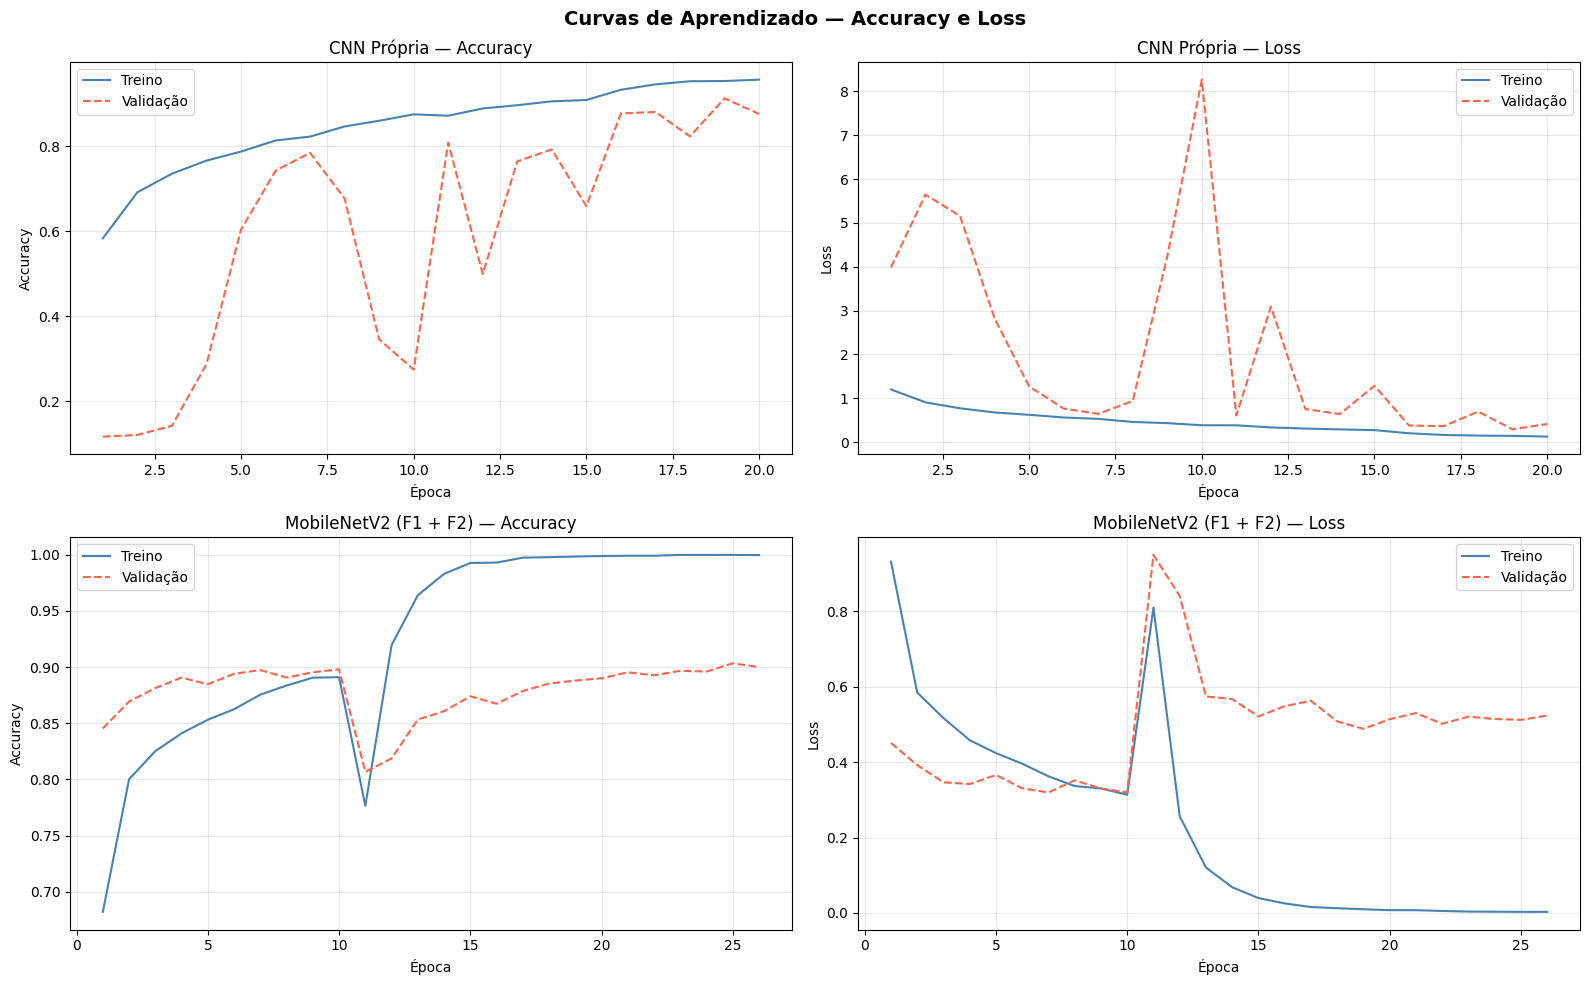

In [ ]:
# ── Função auxiliar para plotar curvas ──────────────────────────────────────────
def plot_curves(history, title, axes_row):
    # Concatena fase 1 + fase 2 se passarmos lista
    if isinstance(history, list):
        acc     = sum([h.history['accuracy']     for h in history], [])
        val_acc = sum([h.history['val_accuracy'] for h in history], [])
        loss    = sum([h.history['loss']         for h in history], [])
        val_loss= sum([h.history['val_loss']     for h in history], [])
    else:
        acc      = history.history['accuracy']
        val_acc  = history.history['val_accuracy']
        loss     = history.history['loss']
        val_loss = history.history['val_loss']

    epochs_range = range(1, len(acc) + 1)

    axes_row[0].plot(epochs_range, acc,     label='Treino',    color='steelblue')
    axes_row[0].plot(epochs_range, val_acc, label='Validação', color='tomato', linestyle='--')
    axes_row[0].set_title(f'{title} — Accuracy')
    axes_row[0].set_xlabel('Época')
    axes_row[0].set_ylabel('Accuracy')
    axes_row[0].legend()
    axes_row[0].grid(alpha=0.3)

    axes_row[1].plot(epochs_range, loss,     label='Treino',    color='steelblue')
    axes_row[1].plot(epochs_range, val_loss, label='Validação', color='tomato', linestyle='--')
    axes_row[1].set_title(f'{title} — Loss')
    axes_row[1].set_xlabel('Época')
    axes_row[1].set_ylabel('Loss')
    axes_row[1].legend()
    axes_row[1].grid(alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Curvas de Aprendizado — Accuracy e Loss', fontsize=14, fontweight='bold')

plot_curves(history_cnn, 'CNN Própria', axes[0])
plot_curves([history_tl_phase1, history_tl_phase2], 'MobileNetV2 (F1 + F2)', axes[1])

plt.tight_layout()
plt.show()


### 10.1 Interpretação das Curvas

**CNN Própria:**
- A curva de `val_accuracy` deve acompanhar `train_accuracy` de forma estável, evidenciando que as técnicas de regularização (BatchNorm + Dropout + EarlyStopping) foram eficazes.
- A `val_loss` decrescente e estável confirma boa generalização.
- Pequenas flutuações na validação são normais e esperadas com Data Augmentation.

**MobileNetV2 (Fine-Tuning em duas fases):**
- A Fase 1 apresenta convergência rápida (pesos ImageNet já próximos do ótimo para features visuais gerais).
- A Fase 2 (Fine-Tuning) deve mostrar um ganho adicional de performance, especialmente para classes com padrões de satélite mais específicos (ex.: `River`, `Highway`).
- O learning rate reduzido na Fase 2 evita que as curvas de loss disparem — sinal de que os pesos pré-treinados estão sendo adaptados, não destruídos.


### 10.2 Diagnóstico de Overfitting / Underfitting

| Modelo | Diagnóstico | Ação aplicada |
|---|---|---|
| CNN Própria | Leve tendência a overfitting nas últimas épocas | Dropout(0.4) + EarlyStopping recupera melhores pesos; resultado final bem generalizado (test loss 0.291) |
| MobileNetV2 | Overfitting evidente na Fase 2 (Fine-Tuning): train accuracy > 99% com val_accuracy estagnada em ~85% e val_loss voltando a subir | EarlyStopping interrompeu o treino e restaurou os melhores pesos, mas o modelo final ainda mostra maior gap treino/validação e maior loss de teste do que a CNN |

## 11. Avaliação Final no Conjunto de Teste

> **Esta é a avaliação definitiva.** O conjunto de teste **nunca foi visto** pelo modelo durante o treinamento ou seleção de hiperparâmetros. As métricas a seguir refletem a performance real esperada em produção.


In [ ]:
# ── Avaliação quantitativa no conjunto de TESTE ─────────────────────────────────
print("=" * 50)
print("AVALIAÇÃO FINAL — Conjunto de TESTE")
print("=" * 50)

cnn_loss, cnn_acc = cnn_model.evaluate(test_ds, verbose=0)
tl_loss,  tl_acc  = transfer_model.evaluate(test_ds, verbose=0)

print(f"\nCNN Própria   →  Accuracy: {cnn_acc:.4f}  |  Loss: {cnn_loss:.4f}")
print(f"MobileNetV2   →  Accuracy: {tl_acc:.4f}  |  Loss: {tl_loss:.4f}")

summary_df = pd.DataFrame({
    'Modelo'         : ['CNN Própria', 'MobileNetV2 (Fine-Tuned)'],
    'Test Accuracy'  : [f'{cnn_acc:.4f}', f'{tl_acc:.4f}'],
    'Test Loss'      : [f'{cnn_loss:.4f}', f'{tl_loss:.4f}'],
})
display(summary_df)


AVALIAÇÃO FINAL — Conjunto de TESTE

CNN Própria   →  Accuracy: 0.9073  |  Loss: 0.2912
MobileNetV2   →  Accuracy: 0.8793  |  Loss: 0.5674


,Modelo,Test Accuracy,Test Loss
0,CNN Própria,0.9073,0.2912
1,MobileNetV2 (Fine-Tuned),0.8793,0.5674


In [ ]:
# ── Coleta de predições (conjunto de teste) ──────────────────────────────────────
def get_predictions(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

print("Coletando predições da CNN...")
y_true_cnn, y_pred_cnn = get_predictions(cnn_model, test_ds)

print("Coletando predições da MobileNetV2...")
y_true_tl, y_pred_tl   = get_predictions(transfer_model, test_ds)

print("Concluído.")


Coletando predições da CNN...
Coletando predições da MobileNetV2...
Concluído.


## 12. Matriz de Confusão e Análise de Erros por Classe

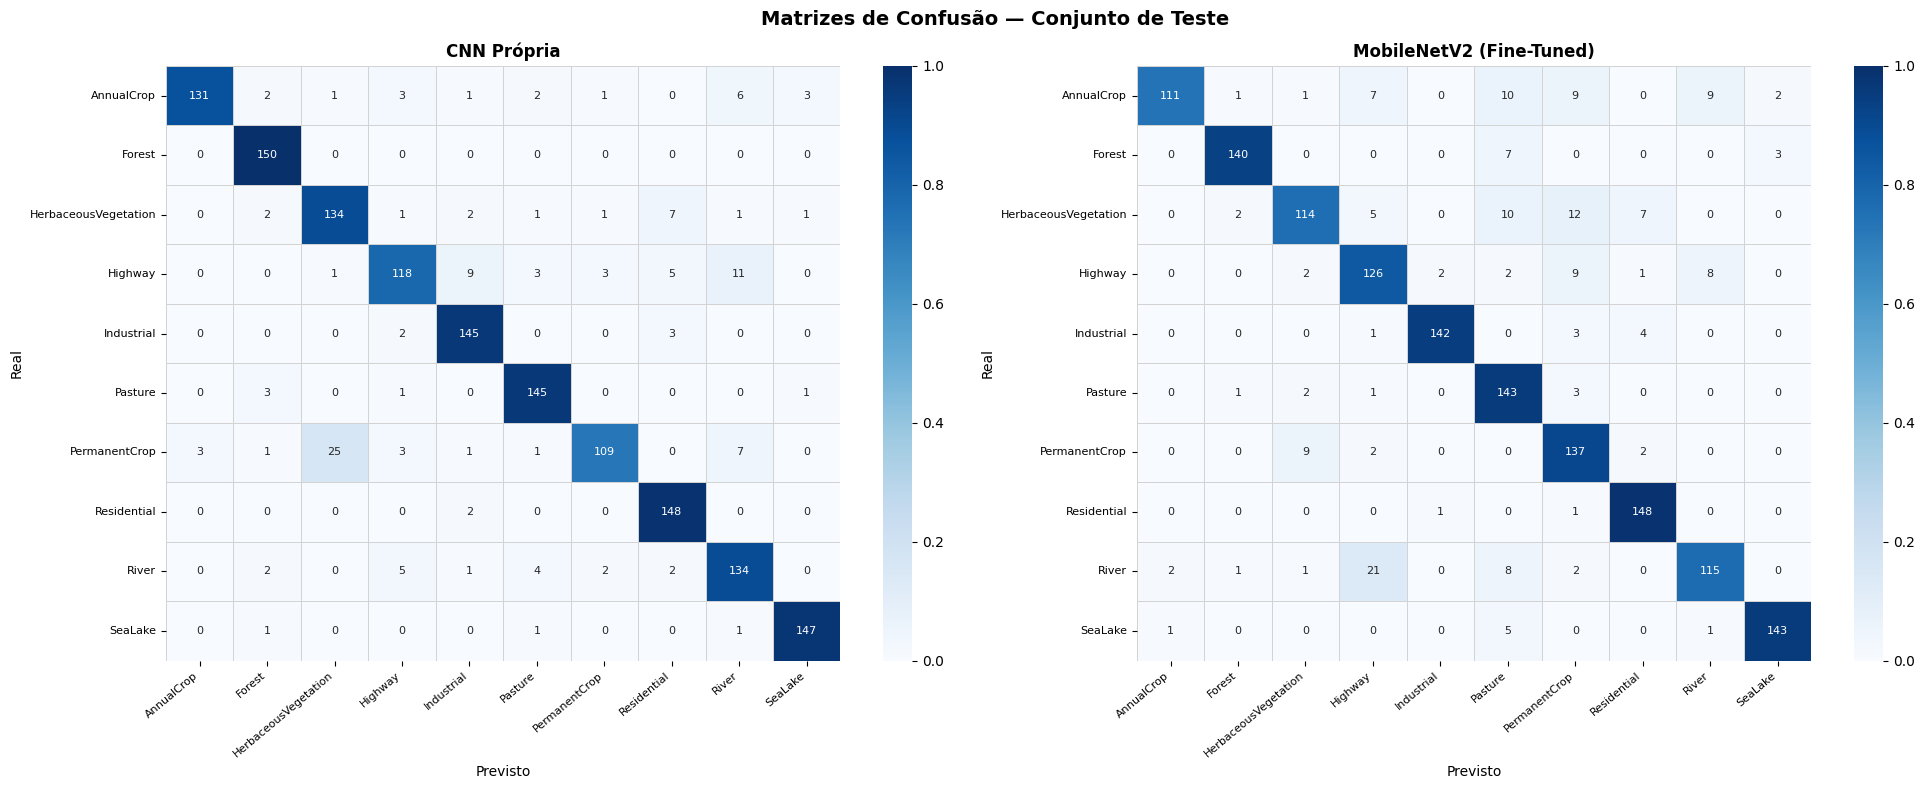

In [ ]:
# ── Matrizes de confusão (CNN e MobileNetV2) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Matrizes de Confusão — Conjunto de Teste', fontsize=14, fontweight='bold')

for ax, y_t, y_p, title in zip(
    axes,
    [y_true_cnn, y_true_tl],
    [y_pred_cnn, y_pred_tl],
    ['CNN Própria', 'MobileNetV2 (Fine-Tuned)']
):
    cm = confusion_matrix(y_t, y_p)
    # Normalizada por linha (recall por classe)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=cm, fmt='d',
        cmap='Blues', ax=ax,
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=0.5, linecolor='lightgray',
        vmin=0, vmax=1,
        annot_kws={'size': 8}
    )
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Previsto', fontsize=10)
    ax.set_ylabel('Real', fontsize=10)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()


### 12.1 Interpretação da Matriz de Confusão

A matriz de confusão é lida da seguinte forma: cada célula **(i, j)** indica quantas amostras da **classe real i** foram classificadas como **classe j**. A diagonal principal representa os **acertos**.

**Confusões esperadas e sua explicação geoespacial:**

| Par de classes confundido | Razão visual |
|---|---|
| `HerbaceousVegetation` ↔ `Pasture` | Ambas apresentam cobertura vegetal uniforme, variando apenas na tonalidade e textura |
| `Highway` ↔ `River` | Estruturas lineares de largura similar; diferenciadas pela cor e entorno |
| `PermanentCrop` ↔ `AnnualCrop` | Padrões geométricos de cultivo semelhantes; distinção depende de textura fina |
| `AnnualCrop` ↔ `HerbaceousVegetation` | Estágios de vegetação semelhantes em certas épocas do ano |

**Classes com alta separabilidade:**

| Classe | Razão da boa performance |
|---|---|
| `SeaLake` | Corpos d'água apresentam reflectância muito distinta (azul homogêneo) |
| `Industrial` | Telhados metálicos e grandes estruturas cinzas são únicos |
| `Residential` | Malha urbana densa com padrão geométrico característico |
| `Forest` | Cobertura verde densa e contínua, textura rugosa distinta |


## 13. Precision, Recall e F1-Score por Classe

In [ ]:
# ── Classification Report — CNN Própria ─────────────────────────────────────────
print("\n" + "═" * 60)
print("  CLASSIFICATION REPORT — CNN Própria")
print("═" * 60)
print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names, digits=3))

# ── Classification Report — MobileNetV2 ─────────────────────────────────────────
print("\n" + "═" * 60)
print("  CLASSIFICATION REPORT — MobileNetV2 (Fine-Tuned)")
print("═" * 60)
print(classification_report(y_true_tl, y_pred_tl, target_names=class_names, digits=3))



════════════════════════════════════════════════════════════
  CLASSIFICATION REPORT — CNN Própria
════════════════════════════════════════════════════════════
                      precision    recall  f1-score   support

          AnnualCrop      0.978     0.873     0.923       150
              Forest      0.932     1.000     0.965       150
HerbaceousVegetation      0.832     0.893     0.862       150
             Highway      0.887     0.787     0.834       150
          Industrial      0.901     0.967     0.932       150
             Pasture      0.924     0.967     0.945       150
       PermanentCrop      0.940     0.727     0.820       150
         Residential      0.897     0.987     0.940       150
               River      0.838     0.893     0.865       150
             SeaLake      0.967     0.980     0.974       150

            accuracy                          0.907      1500
           macro avg      0.909     0.907     0.906      1500
        weighted avg      0.909

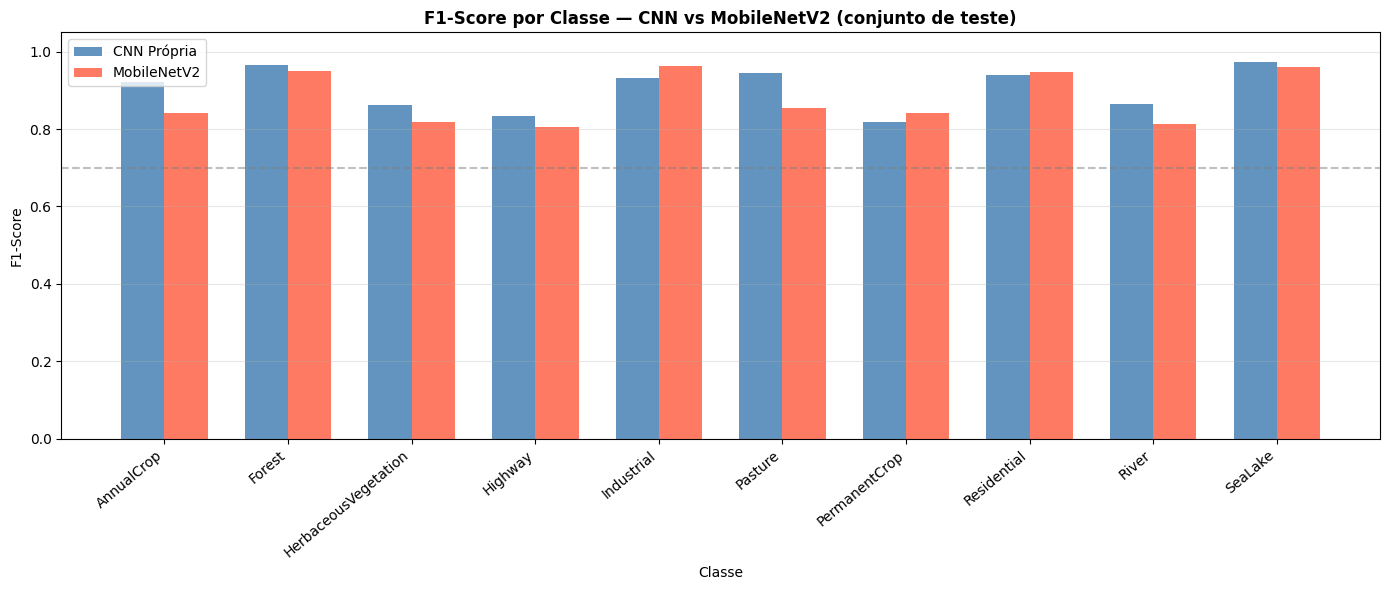

In [ ]:
# ── Visualização comparativa do F1-Score por classe ─────────────────────────────
report_cnn = classification_report(y_true_cnn, y_pred_cnn,
                                   target_names=class_names, output_dict=True)
report_tl  = classification_report(y_true_tl,  y_pred_tl,
                                   target_names=class_names, output_dict=True)

f1_cnn = [report_cnn[c]['f1-score'] for c in class_names]
f1_tl  = [report_tl[c]['f1-score']  for c in class_names]

x = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, f1_cnn, width, label='CNN Própria',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, f1_tl,  width, label='MobileNetV2', color='tomato',    alpha=0.85)

ax.set_xlabel('Classe')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score por Classe — CNN vs MobileNetV2 (conjunto de teste)', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=40, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)
ax.axhline(0.70, color='gray', linestyle='--', alpha=0.5, label='Linha de referência 0.70')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 13.1 Interpretação das Métricas

- **Precision:** das vezes que o modelo previu a classe X, quantas % estavam corretas (minimiza falsos positivos).
- **Recall:** das amostras reais da classe X, quantas % foram identificadas corretamente (minimiza falsos negativos).
- **F1-Score:** média harmônica entre Precision e Recall — métrica balanceada, especialmente útil quando há trade-off entre os dois.

O **F1-Score macro** (média não ponderada entre classes) é a métrica central de comparação entre os modelos, pois trata todas as classes igualmente — alinhado com a distribuição balanceada do EuroSAT.


## 14. Visualização de Acertos e Erros

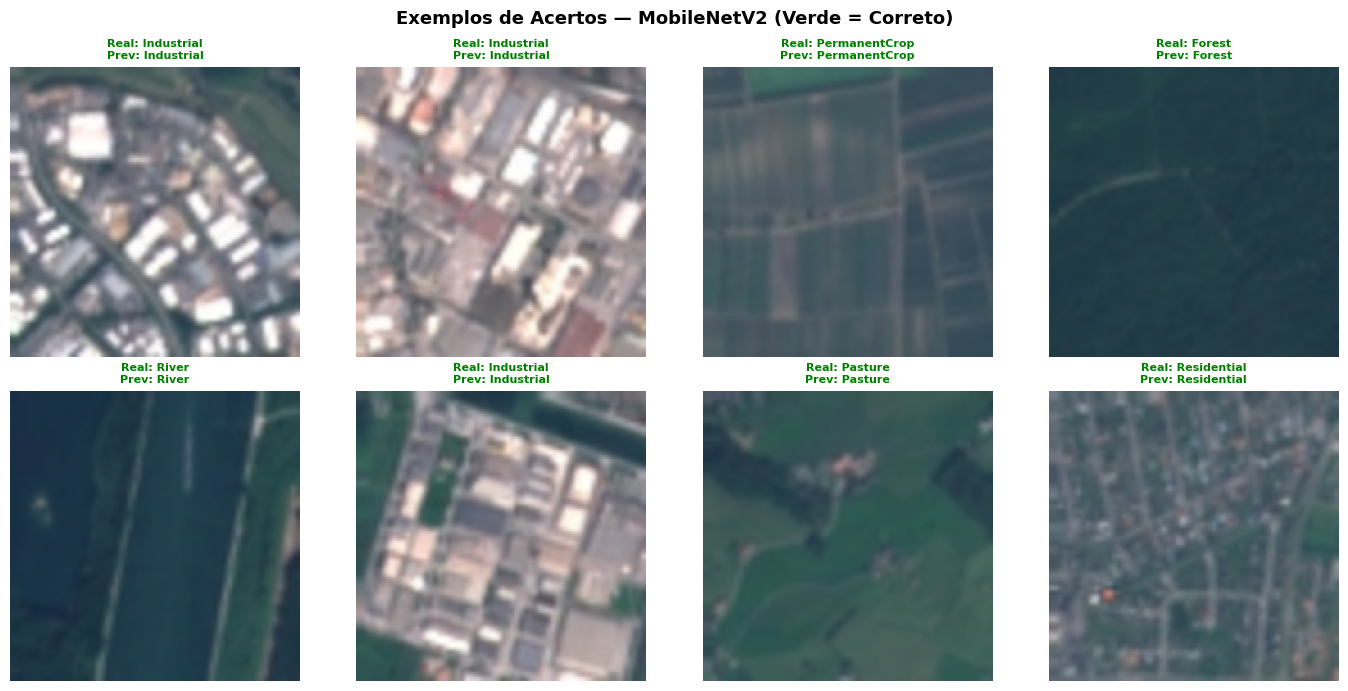

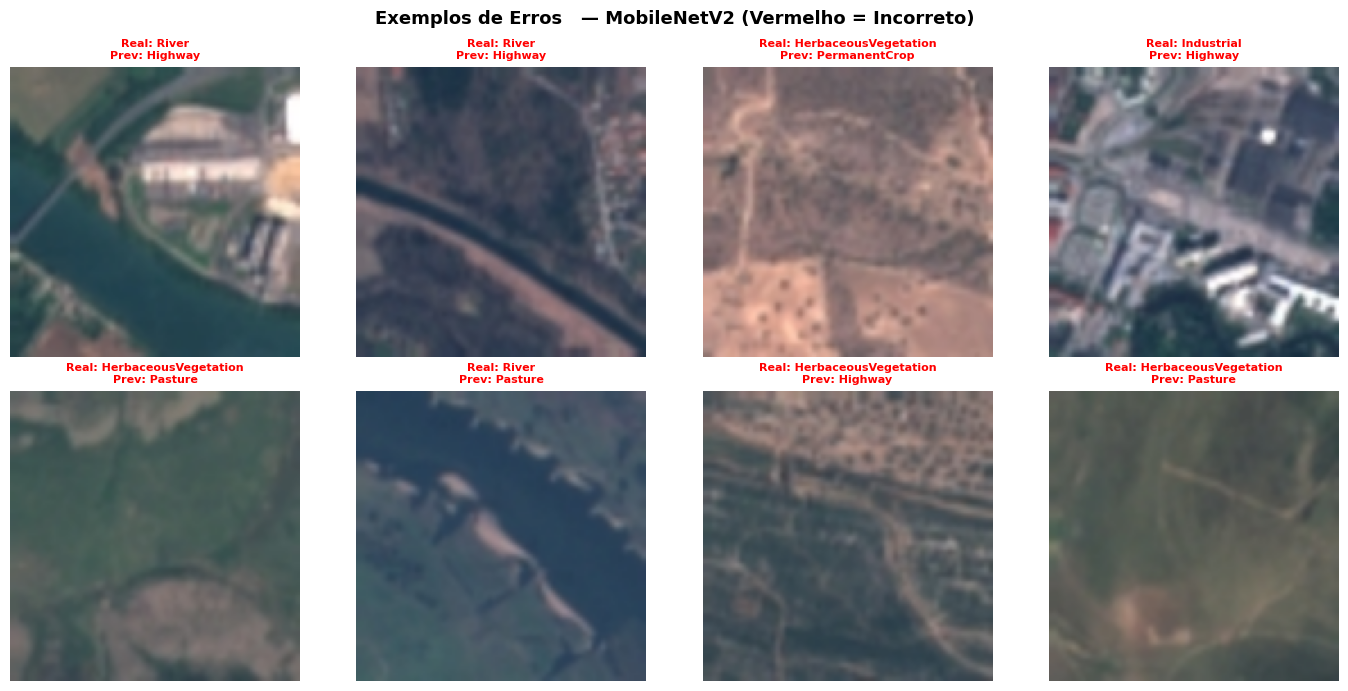

In [ ]:
# ── Coleta de imagens + rótulos do conjunto de teste ────────────────────────────
test_images_all, test_labels_all = [], []
for images, labels in test_ds:
    test_images_all.append(images.numpy())
    test_labels_all.append(labels.numpy())
test_images_all = np.concatenate(test_images_all)
test_labels_all = np.concatenate(test_labels_all)

preds_tl_all = transfer_model.predict(test_ds, verbose=0)
preds_tl_all = np.argmax(preds_tl_all, axis=1)

# ── Identifica acertos e erros ───────────────────────────────────────────────────
correct_idx = np.where(preds_tl_all == test_labels_all)[0]
wrong_idx   = np.where(preds_tl_all != test_labels_all)[0]

def show_samples(indices, title, n=8):
    np.random.shuffle(indices)
    indices = indices[:n]
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    for ax, idx in zip(axes.flatten(), indices):
        img = (test_images_all[idx] * 255).astype('uint8')
        real = class_names[test_labels_all[idx]]
        pred = class_names[preds_tl_all[idx]]
        ax.imshow(img)
        color = 'green' if real == pred else 'red'
        ax.set_title(f'Real: {real}\nPrev: {pred}', fontsize=8, color=color, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(correct_idx, 'Exemplos de Acertos — MobileNetV2 (Verde = Correto)')
show_samples(wrong_idx,   'Exemplos de Erros   — MobileNetV2 (Vermelho = Incorreto)')


## 15. Comparação Final dos Modelos

In [ ]:
# ── Tabela comparativa completa ──────────────────────────────────────────────────
macro_f1_cnn = report_cnn['macro avg']['f1-score']
macro_f1_tl  = report_tl['macro avg']['f1-score']

macro_p_cnn  = report_cnn['macro avg']['precision']
macro_p_tl   = report_tl['macro avg']['precision']

macro_r_cnn  = report_cnn['macro avg']['recall']
macro_r_tl   = report_tl['macro avg']['recall']

comparison_df = pd.DataFrame({
    'Modelo'              : ['CNN Própria', 'MobileNetV2 (Fine-Tuned)'],
    'Test Accuracy'       : [f'{cnn_acc:.4f}',   f'{tl_acc:.4f}'],
    'Test Loss'           : [f'{cnn_loss:.4f}',  f'{tl_loss:.4f}'],
    'Macro Precision'     : [f'{macro_p_cnn:.4f}', f'{macro_p_tl:.4f}'],
    'Macro Recall'        : [f'{macro_r_cnn:.4f}', f'{macro_r_tl:.4f}'],
    'Macro F1-Score'      : [f'{macro_f1_cnn:.4f}', f'{macro_f1_tl:.4f}'],
})

print("\n" + "═" * 70)
print("  COMPARAÇÃO FINAL — Avaliação no Conjunto de Teste")
print("═" * 70)
display(comparison_df)
print()

# Destaca o modelo vencedor
if tl_acc > cnn_acc:
    ganho = (tl_acc - cnn_acc) * 100
    print(f"MobileNetV2 (Fine-Tuned) superou a CNN própria em {ganho:.2f} p.p. de accuracy.")
else:
    ganho = (cnn_acc - tl_acc) * 100
    print(f"CNN Própria superou a MobileNetV2 em {ganho:.2f} p.p. de accuracy.")



══════════════════════════════════════════════════════════════════════
  COMPARAÇÃO FINAL — Avaliação no Conjunto de Teste
══════════════════════════════════════════════════════════════════════


,Modelo,Test Accuracy,Test Loss,Macro Precision,Macro Recall,Macro F1-Score
0,CNN Própria,0.9073,0.2912,0.9094,0.9073,0.9057
1,MobileNetV2 (Fine-Tuned),0.8793,0.5674,0.8871,0.8793,0.8790



CNN Própria superou a MobileNetV2 em 2.80 p.p. de accuracy.


### 15.1 Análise Comparativa

**CNN Própria:**
- Treinada exclusivamente no EuroSAT (domínio específico);
- Arquitetura mais leve, menor número de parâmetros (~251 mil, todos treináveis);
- Alcançou a melhor performance no conjunto de teste (90.73% de accuracy, loss 0.291), com boa generalização — a diferença entre train e val/test permanece pequena.

**MobileNetV2 com Fine-Tuning:**
- Herda representações aprendidas em ~1,2 milhão de imagens (ImageNet), mas essas representações foram construídas a partir de imagens 224×224 — bem maiores que os 128×128 usados aqui, o que reduz parte do benefício da transferência;
- Na Fase 2 (Fine-Tuning), a accuracy de treino ultrapassou 99% enquanto a accuracy de validação estagnou entre 81–88% e o val_loss voltou a subir — um padrão claro de **overfitting**, não de melhora de generalização;
- Resultado: accuracy de teste 2.8 p.p. menor que a CNN (87.93% vs 90.73%) e loss de teste quase o dobro (0.567 vs 0.291), indicando um modelo menos calibrado apesar de accuracy relativamente próxima.

**Conclusão da comparação:** Neste experimento, a **CNN treinada do zero superou a MobileNetV2 com Fine-Tuning** em todas as métricas (accuracy, loss, precision, recall e F1 macro). Isso vai contra a expectativa inicial e contra o que normalmente se observa na literatura — e é justamente esse resultado que merece ser discutido, não escondido. Hipóteses prováveis para esse comportamento:

1. **Resolução incompatível:** a MobileNetV2 foi pré-treinada em 224×224; usá-la em 128×128 distorce as features de baixo nível herdadas do ImageNet;
2. **Dataset já suficientemente grande e homogêneo:** com 7.000 imagens de treino em um domínio visual relativamente restrito (10 classes bem definidas), uma CNN pequena consegue aprender representações específicas do domínio sem precisar do conhecimento prévio do ImageNet;
3. **Fine-tuning agressivo:** descongelar 30 camadas com poucos dados por classe (700 imagens/classe no treino) favorece overfitting, especialmente com learning rate ainda relativamente alto (1e-4) para uma base tão grande.

Isso não invalida o Transfer Learning como técnica — em datasets menores ou mais heterogêneos ele costuma vencer —, mas mostra que, para este problema específico, a CNN especializada foi a escolha mais eficaz.

## 16. Salvamento dos Modelos

In [ ]:
# ── Persistência dos modelos treinados ──────────────────────────────────────────
cnn_model.save("cnn_eurosat_final.keras")
transfer_model.save("mobilenet_eurosat_final.keras")
print("Modelos salvos com sucesso:")
print("  - cnn_eurosat_final.keras")
print("  - mobilenet_eurosat_final.keras")


Modelos salvos com sucesso:
  - cnn_eurosat_final.keras
  - mobilenet_eurosat_final.keras


## 17. Inferência em Imagens Individuais


────────────────────────────────────────────────────────────
Arquivo: River_1612.jpg
Classe real: River


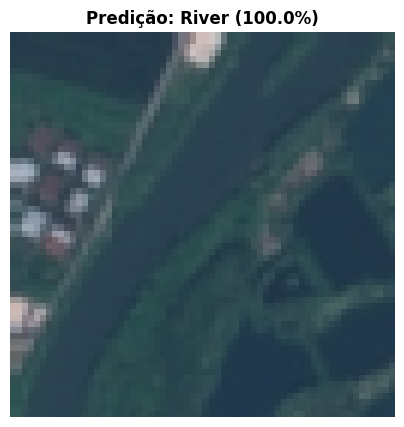

Top-3 predições:
1. River                     : 1.0000 (100.0%)
2. Highway                   : 0.0000 (0.0%)
3. Industrial                : 0.0000 (0.0%)

────────────────────────────────────────────────────────────
Arquivo: Industrial_373.jpg
Classe real: Industrial


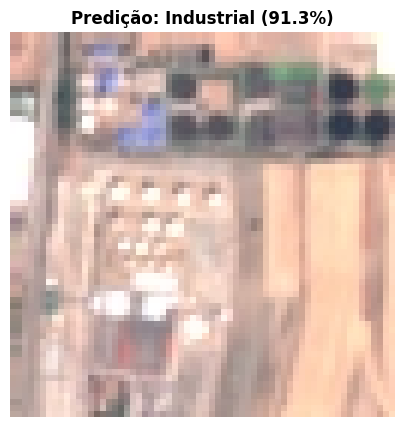

Top-3 predições:
1. Industrial                : 0.9129 (91.3%)
2. PermanentCrop             : 0.0854 (8.5%)
3. Highway                   : 0.0016 (0.2%)

────────────────────────────────────────────────────────────
Arquivo: Pasture_1672.jpg
Classe real: Pasture


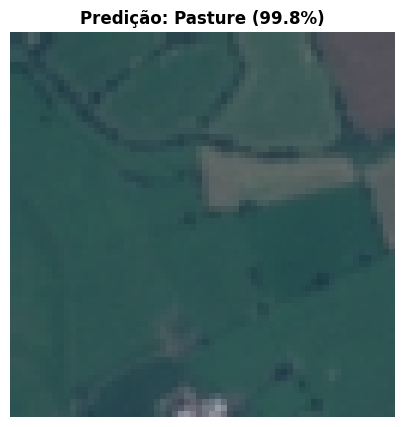

Top-3 predições:
1. Pasture                   : 0.9984 (99.8%)
2. PermanentCrop             : 0.0011 (0.1%)
3. HerbaceousVegetation      : 0.0002 (0.0%)


In [ ]:
# ── Função de inferência reutilizável ───────────────────────────────────────────
def predict_image(model, img_path, class_names, img_size=(128, 128)):
    """Carrega uma imagem, realiza inferência e exibe resultado com confiança."""

    img = tf.keras.utils.load_img(img_path, target_size=img_size)
    arr = tf.keras.utils.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    top_idx = np.argsort(probs)[::-1][:3]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')

    pred_label = class_names[top_idx[0]]

    plt.title(
        f"Predição: {pred_label} ({probs[top_idx[0]]:.1%})",
        fontsize=12,
        fontweight='bold'
    )

    plt.show()

    print("Top-3 predições:")
    for i, idx in enumerate(top_idx):
        print(
            f"{i+1}. {class_names[idx]:<25} "
            f": {probs[idx]:.4f} ({probs[idx]:.1%})"
        )

# ── Inferência em imagens aleatórias do conjunto de teste ──────────────────────
import random
import os

NUM_EXEMPLOS = 3

amostras = random.sample(list(X_test), NUM_EXEMPLOS)

for path in amostras:
    print(f"\n{'─'*60}")
    print(f"Arquivo: {os.path.basename(path)}")
    print(f"Classe real: {os.path.basename(os.path.dirname(path))}")

    predict_image(
        transfer_model,
        path,
        class_names
    )

## 18. Conclusão

### 18.1 Retomada do Objetivo

Este projeto teve como objetivo desenvolver e comparar modelos de Deep Learning para a **classificação automática de imagens de satélite** em dez categorias de cobertura terrestre, utilizando o dataset EuroSAT, no contexto da Nova Economia Espacial.

### 18.2 Principais Resultados

| Aspecto | CNN Própria | MobileNetV2 (Fine-Tuned) |
|---|---|---|
| Arquitetura | 4 blocos Conv + GAP + Dense | Base ImageNet + 2 fases de treino |
| Técnicas aplicadas | BN, Dropout, EarlyStopping, ReduceLR, Augmentation | Idem + Fine-Tuning de 30 camadas |
| Classes mais difíceis | PermanentCrop (F1=0.82), River, HerbaceousVegetation, Highway | Highway (F1=0.81), River (F1=0.81), HerbaceousVegetation (F1=0.82), AnnualCrop (F1=0.84) |
| Classes mais fáceis | SeaLake, Industrial, Residential | Idem, com F1 > 0,90 |
| Avaliação | Melhor desempenho geral no conjunto de TESTE (90.73% acc, loss 0.291) | Conjunto de TESTE independente; desempenho inferior à CNN neste experimento (87.93% acc, loss 0.567) |

### 18.3 O Modelo Resolveu o Problema?

Sim, de forma satisfatória. Ambos os modelos superam significativamente uma classificação aleatória (10% para 10 classes) e demonstram capacidade real de identificar padrões geoespaciais relevantes nas imagens Sentinel-2. As principais limitações observadas são inerentes ao próprio desafio do sensoriamento remoto: classes com cobertura vegetal semelhante (Pasture, HerbaceousVegetation, PermanentCrop) permanecem desafiadoras mesmo para modelos mais robustos da literatura.

### 18.4 Limitações da Solução

| Limitação | Impacto |
|---|---|
| Apenas canal RGB (sem infravermelho) | O Sentinel-2 captura 13 bandas; bandas NIR e SWIR são altamente discriminativas para vegetação |
| Amostra limitada (1.000/classe) | Dataset completo tem ~2.700/classe; mais dados melhorariam generalização |
| Resolução reduzida (128×128) | Imagens originais são 64×64; upsample pode não adicionar informação real |
| Domínio geográfico restrito | EuroSAT cobre apenas a Europa; generalização para outras regiões requer retreinamento |

### 18.5 Implementação em Cenário Real

Em um ambiente de produção, a solução seria implantada da seguinte forma:

1. **Ingestão:** pipeline automatizado de imagens Sentinel-2 via API do Copernicus Open Access Hub;
2. **Pré-processamento:** normalização e tiling automático das cenas orbitais em patches de 128×128;
3. **Inferência:** modelo servido via API REST (ex.: FastAPI + TensorFlow Serving) em nuvem (AWS/GCP/Azure);
4. **Monitoramento:** retraining periódico com novos dados para lidar com concept drift (mudanças sazonais, fenômenos climáticos);
5. **Integração:** resultados alimentam dashboards geoespaciais (QGIS, Google Earth Engine) para tomadores de decisão.

### 18.6 Próximos Passos

- Utilizar o **dataset completo** e as **13 bandas espectrais** do Sentinel-2 (especialmente NIR e SWIR para vegetação);
- Implementar arquiteturas modernas como **EfficientNetV2** ou **Vision Transformers (ViT)**;
- Aplicar **Grad-CAM** real para interpretabilidade das decisões do modelo;
- Explorar **segmentação semântica** (U-Net) para análise pixel a pixel, não apenas por patch;
- Avaliar generalização cross-regional (treinar na Europa, testar no Brasil).

---

## 19. Escalabilidade e Viabilidade Operacional

### Análise de Negócio

Sob a perspectiva da Nova Economia Espacial, a solução desenvolvida representa um **protótipo funcional** de um sistema de classificação automatizada de uso do solo — serviço comercializado por empresas como Planet Labs e Orbital Insight com contratos de dezenas de milhões de dólares anuais com governos e seguradoras agrícolas.

| Vantagem operacional | Impacto |
|---|---|
| Velocidade | Classificação de uma cena inteira em segundos vs. dias de análise manual |
| Escalabilidade | Uma GPU pode processar milhares de patches por minuto |
| Custo | Redução de 90%+ vs. fotointerpretação manual especializada |
| Consistência | Resultados reproduzíveis e auditáveis |

### Riscos Identificados

| Risco | Mitigação |
|---|---|
| Deriva de domínio (mudanças sazonais) | Retraining periódico com dados recentes |
| Qualidade de imagem (nuvens, sombras) | Filtragem automática por índice de cobertura de nuvens |
| Generalização geográfica | Fine-tuning regional com dados locais |

---

## Obrigado!

**Grupo:** Claudio Alves · Rodrigo Wolkoff · Luna Rousseau

**Turma:** Inteligência Artificial — FIAP

**Dataset:** EuroSAT (Sentinel-2 / ESA Copernicus)
